# Submission 1: Your Model, Your Beam: SOLUTION KEY
### ME 323 Module 1 (staff only)

<img src="https://raw.githubusercontent.com/andrewvoss8-boop/core-me-data-science-activities-public/main/me323/Module1_drafts/figures/I_beam_dimensions.jpg" alt="I-beam dimensions" width="220">

Both common class designs have been queried. The scoreboard so far:

| design | (b, H_web) | predicted | returned strength and str/w on estimated-mass basis |
|---|---|---|---|
| equation-query beam from Pre-lab 1 | (1.25, 13.2) | 47.8 N/g | **39.09 N/g** (515.6 N) |
| locked GP-query beam from Pre-lab 2, MUI ψ=1 | (1.44, 13.2) | 38.2 N/g | **38.9 N/g** (533.1 N) |

Both beat the original 14-beam best of 36.88 N/g. The equation beam became
the best of 15 at 39.09 N/g — and it is *still* the best of all 16. The GP
beam returned more raw strength (533.1 N vs 515.6 N) but spent more mass to
get it, so on the strength-to-weight basis the scoreboard runs on, it slots in
second at 38.9 N/g. Relative
to their own predictions, the equation result came in 18.2% low and the GP
result 1.9% above its 38.2 N/g prediction. Sit with that pair of facts: the
winning beam came from the prediction that missed by 18.2%, and the
well-calibrated model got beaten. One test settles less than it seems to.

Both returned strengths came from the staff oracle — the model fit to the
prior test campaign that stands in for the testing machine — so nothing has
been printed yet. That changes here: fold both query results into the data,
build a model your way, and commit to a third design, the beam your group will
actually print and break. Do not call either common query beam your
Submission 1 design unless you deliberately choose those coordinates. The
final answer is a decision defended in the memo.

## Your knobs

This notebook hands you a working pipeline, but every modeling decision in it
is a variable you set — and each one is an assumption about the world, not a
setting with a known right answer. The full dashboard:

| knob | variable (where) | options | the assumption you are making |
|---|---|---|---|
| model architecture | `CHOICE` (§3) | `"A plain"` / `"B strength"` / `"C features"` / `"D residual"` | how much physics the model gets, and what quantity it learns — §2 |
| prediction target | comes with the lane | str/w directly (lanes A, C, D) or raw strength ÷ mass (lane B) | which quantity is the smoother, easier thing to learn — §2 |
| kernel | `KERNEL` (§3) | `"RBF"` / `"Matern"` | how smooth the true strength surface is — §3 |
| assumed noise | `NOISE_PCT` (§3) | any percent; class default 3 | how much of beam-to-beam scatter is repeatability rather than real shape — §3 |
| acquisition rule | `ACQ` (§4) | `"MUI"` / `"EI"` | how predicted value and uncertainty combine into one pick — §4 |
| explore vs exploit | `psi` (§4, MUI only) | 0 = pure exploit; larger = more explore | how much a *chance* at a better beam is worth against a safe, good one — §4 |

Two kinds of knobs, two ways to choose. Architecture and kernel make claims
the data can score, and the leave-one-out table in §2 is their referee. Noise
and ψ make claims the data *cannot* score: no table can tell you the rig's
repeatability or how much risk your group should carry. Those you defend in
the memo with physical reasoning and stated values.

One more thing, since this module keeps saying there is no right answer: that
is a claim about the knobs, not about the grade. The grade follows the
defense, not the distance from the defaults — a defended default recipe
outscores an arbitrary exotic one.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120

# Fixed geometry (you choose b and H_web; everything else is set)
B, TH, L = 10.0, 18.0, 150.0     # flange width, total height, test span (mm)
LP = 172.0                        # printed length (mm); overhangs the 150 mm span
KMASS = 0.2045                    # g/mm^2: mass per unit cross-section area at 172 mm

# Handbook starting values — Pre-lab 1 calibrates the three marked ones
SY = 76e6                         # Pa, PLA strength                 (calibrated)
K_LTB = 0.33                      # fixture effective-length factor  (calibrated)
TAU_I = 43.9e6                    # printed-interface shear strength (Pa) — starting
                                  # guess = bulk yield / sqrt(3)     (calibrated)
E, G = 2.5e9, 2.5e9 / 2.6         # Young's / shear modulus (Pa) — fixed
C1, C2 = 1.35, 0.55               # LTB moment-gradient / load-height factors
URL = ("https://raw.githubusercontent.com/andrewvoss8-boop/"
       "core-me-data-science-activities-public/main/data/student_beams_B10_L150.csv")
try:
    df = pd.read_csv(URL); print("loaded from GitHub")
except Exception:
    try:
        df = pd.read_csv("student_beams_B10_L150.csv"); print("loaded local copy")
    except FileNotFoundError as e:
        raise FileNotFoundError(
            "no internet and no local copy -- download student_beams_B10_L150.csv "
            "from the course page into this notebook's folder and rerun") from e
df = df.rename(columns={"b_mm": "b", "H_web_mm": "H"})

def estimated_mass_g(b, H):
    A = b * H + B * (TH - H)      # cross-section area, mm^2
    return KMASS * A              # grams
df["mass_est_g"] = estimated_mass_g(df.b, df.H)
df["mass_delta_g"] = df.weight_g - df.mass_est_g
df["mass_delta_pct"] = 100*df.mass_delta_g/df.mass_est_g
print(len(df), "tested beams")

new = pd.DataFrame([
    dict(beam_id=15, b=1.25, H=13.2, strength_N=515.6,
         failure_note="equation-query result; observed morphology not supplied"),
    dict(beam_id=16, b=1.44, H=13.2, strength_N=533.1,
         failure_note="locked-GP-query result; observed morphology not supplied"),
])
new["weight_g"] = np.nan
new["mass_est_g"] = estimated_mass_g(new.b, new.H)
df = pd.concat([df, new], ignore_index=True)
df["str_to_weight"] = df.strength_N / df.mass_est_g
print(len(df), "beams. best observed:", round(df.str_to_weight.max(), 2), "N/g")
pd.set_option("display.max_colwidth", None)
print("\nFailure-note evidence available to the design decision:")
print(df[["beam_id", "b", "H", "failure_note"]].to_string(index=False))

loaded from GitHub
14 tested beams
16 beams. best observed: 39.09 N/g

Failure-note evidence available to the design decision:
 beam_id    b    H                                                                                                                            failure_note
       1 7.00 16.0                                                                                Complete vertical fracture across the center of the beam
       2 7.00 10.5                                                                                Complete vertical fracture across the center of the beam
       3 4.85 14.4                                                        Vertical fracture on the bottom of the beam, but not completely through the beam
       4 3.25 15.1                                                        Vertical fracture on the bottom of the beam, but not completely through the beam
       5 3.55  7.5                                                                                

## 1. The calibrated physics (carried over from Pre-lab 1)

Provided complete this time, with the class calibration values baked in.

In [2]:
def section_props(b, H):
    """I-section properties. b, H in mm; everything returned in METERS/SI."""
    tf = (TH - H) / 2.0
    b_, h_, B_, tf_ = b/1e3, H/1e3, B/1e3, tf/1e3
    c = (TH/1e3) / 2
    Ix = (b_*h_**3)/12 + 2*((B_*tf_**3)/12 + B_*tf_*(h_/2 + tf_/2)**2)
    Iy = (h_*b_**3)/12 + 2*(tf_*B_**3)/12
    def J_rect(x, y):
        short, long = min(x, y), max(x, y)
        r = short/long
        beta = 1 - 0.63*r + 0.052*r**5
        return (1/3)*beta*long*short**3
    J = J_rect(b_, h_) + 2*J_rect(tf_, B_)
    Cw = Iy*(h_ + tf_)**2/4
    return dict(Ix=Ix, Iy=Iy, J=J, Cw=Cw, c=c,
                b=b_, h=h_, tf=tf_, B=B_)

def P_bend(p, sy):
    return 4*sy*p["Ix"] / (p["c"] * L/1e3)
def P_LTB(p, sy, k):
    My = sy*p["Ix"]/p["c"]
    Lb, zg = k*L/1e3, p["c"]
    R = p["Cw"]/p["Iy"] + (Lb**2*G*p["J"])/(np.pi**2*E*p["Iy"]) + (C2*zg)**2
    Mcr = C1*np.pi**2*E*p["Iy"]/Lb**2 * (np.sqrt(R) - C2*zg)
    return 4*min(My, Mcr)/(L/1e3)
def Q_flange(p):
    return p["B"]*p["tf"]*(p["h"]/2 + p["tf"]/2)
def P_sep(p, tau_i):
    """Flange-web separation: shear flow vs strength along the printed layer lines."""
    return 2*tau_i*p["Ix"]*p["b"]/Q_flange(p)
def capacity(b, H, sy, k, tau_i):
    """Class model (2026-07-15): plain minimum of the three mode capacities."""
    p = section_props(b, H)
    return min(P_bend(p, sy), P_sep(p, tau_i), P_LTB(p, sy, k))
def gov_mode(b, H, sy, k, tau_i):
    """Dominant pure-mode proxy, not an observed failure-mechanism label."""
    p = section_props(b, H)
    Pb, Ps, Pl = P_bend(p, sy), P_sep(p, tau_i), P_LTB(p, sy, k)
    return "separation" if Ps < min(Pb, Pl) else (
        "LTB" if Pl < 0.999*Pb else "bend")

SY_CAL, K_CAL, TAU_CAL = 6.680e+07, 0.377, 1.791e+07   # your Pre-lab 1 calibration
print("calibrated capacity(2,12) =", round(capacity(2, 12, SY_CAL, K_CAL, TAU_CAL), 1), "N")

calibrated capacity(2,12) = 733.9 N


## 2. Pick a lane: four ways to model the same 16 beams

"Model architecture" here means two choices at once: what the GP sees, and
what quantity it learns.

| lane | what the GP sees | what it predicts |
|---|---|---|
| **A — plain (vanilla GP)** | (b, H_web) | log str/w — the Pre-lab 2 model |
| **B — strength target** | (b, H_web) | log strength; divide by mass afterwards |
| **C — physics features** | (b, H_web, log P_phys, P_LTB/P_bend) | log str/w |
| **D — residual** | (b, H_web) | log(measured / P_phys) — physics first, GP corrects |

What each lane assumes:

- **A — plain (vanilla GP).** A pure pattern-matcher: str/w is a smooth
  function of the two geometry numbers and 16 points are enough to learn it.
  No physics at all — which also means no physics *errors*. Between data
  points it interpolates; far from data it drifts back toward the mean and
  its error bars balloon. That ballooning is honest, and it is also all the
  guidance you get out there.
- **B — strength target.** The same vanilla GP, but it learns raw newtons and
  you divide by estimated mass afterwards. Worth trying if you believe raw
  strength is the smoother surface. The catch: a small percentage error on a
  900 N prediction becomes a large N/g error once you divide by a light
  beam's mass. The LOO table shows how that gamble went here.
- **C — physics features.** The GP still learns str/w, but you hand it two
  extra inputs computed from the calibrated equations: the physics capacity
  and an LTB-to-bending stability ratio. The model can lean on the physics
  where it tracks the data and ignore it where it doesn't — at the cost of
  learning a 4-D input space from the same 16 points.
- **D — residual.** Physics goes first: compute P_phys from the calibrated
  equations, then let the GP learn only the correction factor
  (measured / physics). Where the equations are right the GP has nothing to
  do; where they are biased it learns the bias. This carries physics shape
  into regions with no data — the strongest extrapolator of the four — and it
  inherits every blind spot of the equations, including any mechanism they
  leave out entirely.

**How to discern:** the leave-one-out (LOO) table below scores each lane on a
beam it did not see, sixteen times over — a dress rehearsal for predicting
your un-printed design. Low LOO RMSE is real evidence. It is also 16-point
evidence: a lane that wins by 0.3 N/g is a coin flip; a lane that loses by
3 N/g is genuinely worse. Following the winner is a defensible move when you
argue it (for instance: "D wins under both kernels, and my candidate sits
inside the tested region, where its physics is anchored by data"). So is
overruling it (for instance: "D wins LOO, but I am designing near the thin-web
region where its physics is blind to separation"). Either can earn full
credit; a lane chosen with no argument cannot.

**Be clear about what these scores are: they measure how well each lane
predicts the beams we already have, from very limited data. A model can carry
big errors in zones that do not matter and still nail the neighborhood of the
optimum — or the reverse. The table says nothing about how well a lane will
search the space once Bayesian optimization starts steering it. It is one
indicator of model accuracy under sixteen points, not a verdict.**

In [3]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, RBF, Matern

def make_kernel(kernel, ndim):
    """The smoothness assumption, written as code.
    RBF:    infinitely differentiable — believes the strength surface is
            gentle everywhere; can round over a sharp failure-mode handoff.
    Matern: nu = 2.5, twice differentiable — believes the surface may carry
            kinks, e.g. where the governing failure mode changes."""
    if kernel == "RBF":
        return C(1.0, (1e-3, 1e3)) * RBF([1.0]*ndim, (1e-1, 30.0))
    elif kernel == "Matern":
        return C(1.0, (1e-3, 1e3)) * Matern([1.0]*ndim, (1e-1, 30.0), nu=2.5)
    raise ValueError(f"unknown kernel {kernel!r}: use 'RBF' or 'Matern'")

def fit_gp(data, alpha=0.03**2, feats=("b", "H"), target="log_sw", kernel="RBF"):
    """The class GP recipe: z-scored inputs, log target, MLE hyperparameters."""
    X = data[list(feats)].values.astype(float)
    fmu, fsd = X.mean(0), X.std(0) + 1e-12
    if target == "log_sw":
        y = np.log(data.strength_N.values /
                   estimated_mass_g(data.b.values, data.H.values))
    elif target == "log_strength":
        y = np.log(data.strength_N.values.astype(float))
    else:                                    # log residual vs calibrated physics
        Pphys = np.array([capacity(b, H, SY_CAL, K_CAL, TAU_CAL)
                          for b, H in zip(data.b, data.H)])
        y = np.log(data.strength_N.values) - np.log(Pphys)
    ymean = y.mean()
    gp = GaussianProcessRegressor(make_kernel(kernel, X.shape[1]), alpha=alpha,
                                  normalize_y=False,
                                  n_restarts_optimizer=5, random_state=0)
    gp.fit((X - fmu) / fsd, y - ymean)
    return gp, fmu, fsd, ymean

def predict_sw(gp, fmu, fsd, ymean, bq, Hq, target, feats):
    Xq = build_feats(bq, Hq, feats)
    mu, sd = gp.predict((Xq - fmu)/fsd, return_std=True)
    mu = mu + ymean
    mass = estimated_mass_g(np.asarray(bq, float), np.asarray(Hq, float))
    if target == "log_sw":
        sw = np.exp(mu)
    elif target == "log_strength":
        sw = np.exp(mu)/mass
    else:
        Pphys = np.array([capacity(b, H, SY_CAL, K_CAL, TAU_CAL)
                          for b, H in zip(np.atleast_1d(bq), np.atleast_1d(Hq))])
        sw = Pphys*np.exp(mu)/mass
    return sw, sd

def build_feats(bq, Hq, feats):
    bq, Hq = np.atleast_1d(np.asarray(bq, float)), np.atleast_1d(np.asarray(Hq, float))
    cols = {"b": bq, "H": Hq}
    if "logP" in feats or "stab" in feats:
        pp = [section_props(b, H) for b, H in zip(bq, Hq)]
        Pb = np.array([P_bend(p, SY_CAL) for p in pp])
        Pl = np.array([P_LTB(p, SY_CAL, K_CAL) for p in pp])
        Ps = np.array([P_sep(p, TAU_CAL) for p in pp])
        cols["logP"] = np.log(np.minimum(Pb, np.minimum(Ps, Pl)))
        cols["stab"] = Pl/Pb
    return np.column_stack([cols[f] for f in feats])

LANES = {
    "A plain":    dict(feats=("b", "H"), target="log_sw"),
    "B strength": dict(feats=("b", "H"), target="log_strength"),
    "C features": dict(feats=("b", "H", "logP", "stab"), target="log_sw"),
    "D residual": dict(feats=("b", "H"), target="log_residual"),
}

def fit_lane(data, lane, alpha=0.03**2, kernel="RBF"):
    cfg = LANES[lane]
    d2 = data.copy()
    Xf = build_feats(d2.b.values, d2.H.values, cfg["feats"])
    for j, f in enumerate(cfg["feats"]):
        d2[f] = Xf[:, j]
    gp, fmu, fsd, ymean = fit_gp(d2, alpha=alpha, feats=cfg["feats"],
                                 target=cfg["target"], kernel=kernel)
    return gp, fmu, fsd, ymean, cfg

print("leave-one-out RMSE in str/w space (lower is better):")
for kernel in ("RBF", "Matern"):
    print(f"  kernel = {kernel}")
    for lane in LANES:
        errs = []
        for i in range(len(df)):
            tr = df.drop(df.index[i])
            gp_, fmu_, fsd_, ym_, cfg_ = fit_lane(tr, lane, kernel=kernel)
            sw_hat, _ = predict_sw(gp_, fmu_, fsd_, ym_, df.b.iloc[i], df.H.iloc[i],
                                   cfg_["target"], cfg_["feats"])
            errs.append(sw_hat[0] - df.str_to_weight.iloc[i])
        print(f"    {lane}: {np.sqrt(np.mean(np.array(errs)**2)):.2f} N/g")
print("\nCHECKPOINT (RBF):    roughly A plain 2.94,  B strength 5.95,  C features 3.54,  D residual 2.00 N/g.")
print("CHECKPOINT (Matern): roughly A plain 3.23,  B strength 5.45,  C features 3.43,  D residual 1.85 N/g.")
print("Within about 0.1 N/g of these counts as matching -- library versions")
print("wobble the fits. Off by 0.5 N/g or more, check your work or talk to a TA.")

leave-one-out RMSE in str/w space (lower is better):
  kernel = RBF


    A plain: 2.94 N/g


    B strength: 5.95 N/g


    C features: 3.54 N/g


    D residual: 2.00 N/g
  kernel = Matern


    A plain: 3.23 N/g


    B strength: 5.45 N/g


    C features: 3.43 N/g


    D residual: 1.85 N/g

CHECKPOINT (RBF):    roughly A plain 2.94,  B strength 5.95,  C features 3.54,  D residual 2.00 N/g.
CHECKPOINT (Matern): roughly A plain 3.23,  B strength 5.45,  C features 3.43,  D residual 1.85 N/g.
Within about 0.1 N/g of these counts as matching -- library versions
wobble the fits. Off by 0.5 N/g or more, check your work or talk to a TA.


## 3. Rebuild the maps with your knobs

Three knobs live in the next cell. Set them, refit on all 16 beams, and look
at the surfaces you will decide from.

**`KERNEL` — how smooth do you believe the strength surface is?**
The kernel is the GP's smoothness assumption; `make_kernel` above is where it
becomes code.

- `"RBF"` assumes an infinitely smooth surface: strength varies gently, and
  each data point says a lot about its whole neighborhood. If the truth has a
  crease — say, where the governing failure mode hands off from bending to
  flange-web separation — RBF rounds it over.
- `"Matern"` (ν = 2.5) assumes less: the surface may carry kinks, and a data
  point speaks a bit less confidently about its neighbors.

How to discern: the LOO table in §2 now scores both kernels, so start there —
remembering the 16-point caveat. Then ask whether you believe this surface
*has* a crease: the failure-note table says different beams died by different
mechanisms, which is an argument that it does.

**`NOISE_PCT` — how much of the scatter do you trust?**
The GP receives `alpha = (NOISE_PCT/100)**2` in log space, which reads as:
"an identical beam, printed and tested again, comes back within roughly
NOISE_PCT percent." Small values force the fit to thread every data point —
every wiggle is treated as real shape. Large values let it smooth through
them — much of the wiggle is print luck and rig luck. Assuming somewhat more
noise than you believe — say 5% — can be a deliberate move: it stabilizes and
smooths the fit, guarding against overfitting sixteen points, at the price of
muting real features. No cell in this
notebook can compute the right value: the 16 beams contain no repeated
geometry, so the data cannot measure its own error bar. The best physical
anchor available is the staff campaign behind the oracle: four repeat prints
of one design spanned 548.6 to 566.1 N — about a 3% spread — and pooled
across every repeated geometry there, the scatter ran near 4%, with
print-session structure inside it. That brackets a defensible range; it does
not pick your number. This knob is an assumption. The honest move is to state
your number, and to know what it did to your answer — try 1 and 8 and watch
where the recommendation moves before you commit.

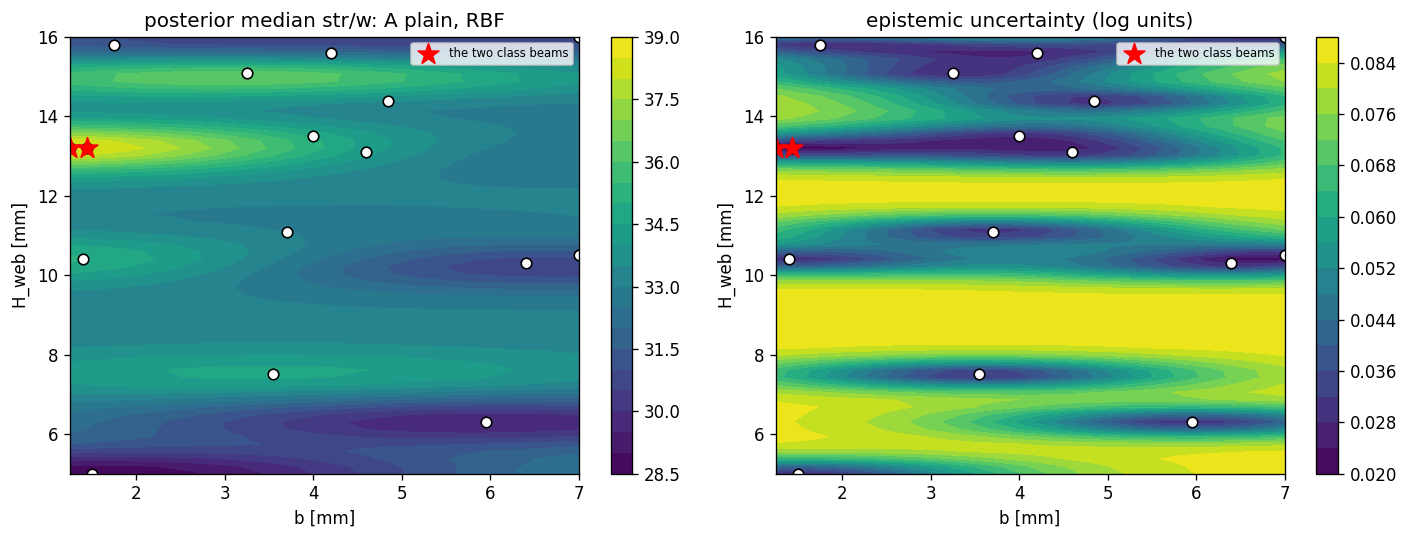

In [4]:
CHOICE    = "A plain"   # <<< your lane:   "A plain" | "B strength" | "C features" | "D residual"
KERNEL    = "RBF"       # <<< your smoothness assumption: "RBF" | "Matern"
NOISE_PCT = 3           # <<< your assumed repeatability, percent

gpF, fmuF, fsdF, ymF, cfgF = fit_lane(df, CHOICE, alpha=(NOISE_PCT/100)**2,
                                      kernel=KERNEL)
bg = np.linspace(1.25, 7.0, 60); Hg = np.linspace(5.0, 16.0, 60)
BB, HH = np.meshgrid(bg, Hg)
SWg, SDg = predict_sw(gpF, fmuF, fsdF, ymF, BB.ravel(), HH.ravel(),
                      cfgF["target"], cfgF["feats"])
MU, STD = SWg.reshape(BB.shape), SDg.reshape(BB.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
for a, Z, t in [(ax[0], MU, f"posterior median str/w: {CHOICE}, {KERNEL}"),
                (ax[1], STD, "epistemic uncertainty (log units)")]:
    cf = a.contourf(BB, HH, Z, levels=20); fig.colorbar(cf, ax=a)
    a.scatter(df.b, df.H, c="w", edgecolor="k", s=40)
    a.scatter(df.b.iloc[-2:], df.H.iloc[-2:], c="red", marker="*", s=170,
              label="the two class beams")
    a.set_xlabel("b [mm]"); a.set_ylabel("H_web [mm]"); a.set_title(t); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 4. Choose your beam *(you write this — graded on the memo, not a checkpoint)*

The maps give you two numbers at every candidate design: `MU`, the predicted
str/w, and `STD`, how unsure the model is there (log units). An *acquisition
rule* collapses the two maps into one pick. Two rules are wired in:

- **`ACQ = "MUI"` — maximum upper interval, as in Pre-lab 2.**
  `score = log(MU) + psi*STD`: judge every design by its optimistic upper
  bound. `psi` is the explore–exploit dial, and it is yours to set.
  `psi = 0` ignores uncertainty and picks the best posterior median — pure
  exploitation. `psi = 1` credits each design one sigma of upside. Large
  `psi` chases the unexplored corners of the map. There is no correct value:
  ψ says how much your group values a *chance* at a better beam over a safe,
  good one. A well-reasoned ψ sounds like: "ψ = 0.5 — we get
  one print, the best beam tested so far already gives 39.09 N/g, and a
  gamble that fails leaves us nothing to show for it, so we mostly stick with
  what the model predicts well and give unexplored designs only a small
  benefit of the doubt." A weak one sounds like: "ψ = 1, because that is the
  default." Any value can earn full credit; only the second kind of reasoning
  cannot.
- **`ACQ = "EI"` — expected improvement.** Averages the improvement over the
  incumbent best tested beam (39.09 N/g) under the model's own uncertainty.
  No dial: it trades explore against exploit automatically, and it goes to
  zero wherever the model is confident nothing beats the incumbent.

How to discern: pick MUI when you want the risk dial in your own hands and
are prepared to defend a ψ in the memo; pick EI when you would rather let the
model's probabilities make the trade — and defend *that* delegation instead.
With the default lane, kernel, and noise, both rules land on the same beam;
if your knob settings make them split, the disagreement itself is worth a
memo sentence.

Whatever the rule says, you hold a veto. The calibrated physics (`capacity`)
and the failure-note table are also in front of you — the standard move is to
strike regions the notes make you distrust (which beams peeled apart, and
where?).

For orientation only: the *default* recipe — lane A, RBF, 3% noise, MUI
ψ = 1 — lands at **(b ≈ 1.25, H_web ≈ 13.39)**. You are free to submit
that; you are also free to beat it. Say why either way.

One deliberate difference from Pre-lab 2: the class-query steps *excluded*
already-tested designs, because a shared oracle query spent on a known point is
wasted. Your print is yours to spend, so the default recipe above applies no
such exclusion -- and in fact its pick lands inside that radius, next to tested beam 15 at (1.25, 13.2). **If your pick lands within the Pre-lab 2
exclusion radius (|Δb| < 0.15 mm, |ΔH_web| < 0.30 mm) of a tested beam, the
memo must say what a near-replicate print buys you.** Verifying a suspiciously
good result is a legitimate answer; sleepwalking into a repeat is not.

In [5]:
from scipy.stats import norm

ACQ = "MUI"          # <<< your rule: "MUI" | "EI"
psi = 1.0            # <<< your explore-exploit dial (MUI only): 0 = pure exploit

if ACQ == "MUI":
    score = np.log(MU) + psi*STD              # optimistic upper bound, log space
elif ACQ == "EI":
    best = np.log(df.str_to_weight.max())     # incumbent: best tested str/w
    z = (np.log(MU) - best) / STD
    score = STD * (z*norm.cdf(z) + norm.pdf(z))
else:
    raise ValueError(f"unknown ACQ {ACQ!r}: use 'MUI' or 'EI'")

i = np.unravel_index(np.argmax(score), score.shape)
b_final, H_final = float(BB[i]), float(HH[i])
print(f"FINAL DESIGN ({ACQ}):  b = {b_final:.2f} mm,  H_web = {H_final:.2f} mm")
print(f"  posterior median {MU[i]:.1f} N/g,  epistemic sigma_log {STD[i]:.3f},  "
      f"calibrated physics {capacity(b_final, H_final, SY_CAL, K_CAL, TAU_CAL)/estimated_mass_g(b_final, H_final):.1f} N/g")
print(f"  physics mode there: {gov_mode(b_final, H_final, SY_CAL, K_CAL, TAU_CAL)}")

FINAL DESIGN (MUI):  b = 1.25 mm,  H_web = 13.39 mm
  posterior median 38.2 N/g,  epistemic sigma_log 0.035,  calibrated physics 46.7 N/g
  physics mode there: LTB


## Memo

Write it in markdown cells below this one, answering these four prompts in
order — about half a page in total. It covers only these prompts; the pre-lab
questions stay in their own notebooks.

1. The two class beams: use the generated scoreboard percentages, with their
   stated denominators. What does each miss reveal, and which miss is costlier
   for the intended design decision?
2. Your lane and kernel: what did the LOO table say under both kernels, and
   did you follow it? If you chose C or D, what does physics contribute
   between the observations?
3. Risk: name your acquisition rule (`ACQ`, plus `psi` if MUI) and your
   `NOISE_PCT`, and use the printed posterior median, epistemic sigma, and
   final coordinates to explain whether you exploited or explored. Is the
   main risk a weak beam or a model that is confidently wrong?
4. Limits: compare your coordinates with the thin-web flange-web-separation
   notes. Where could that unmodeled mechanism affect your design?

The default-parameter design is already computed by the section-4 code. You do
not need a new optimization cell unless you choose a different decision rule.

## KEY: memo targets

1. The scoreboard supplies the actual errors. Overprediction is a capacity-risk
   problem; underprediction is usually a mass/opportunity-cost problem. A strong
   answer distinguishes the denominator instead of comparing ambiguous
   percentages — and notices that the best beam of 16 came from the model with
   the larger miss.
2. Report the generated LOO ordering and at least one beam-level miss. The lane
   ordering holds under both kernels (D residual best at 2.00 RBF /
   1.85 Matérn; B strength worst at 5.95 / 5.45). Matérn
   helps the residual lane a little and hurts the plain lane a little; a strong
   answer ties the kernel choice to a belief about failure-mode creases in the
   surface rather than treating 0.1–0.3 N/g LOO differences as decisive.
   Following the lowest RMSE is acceptable but not mandatory if the model-risk
   argument is specific. Physics-informed lanes carry shape outside the data
   but also inherit the calibrated capacity model's omissions (no local plate
   buckling or web crippling, and a single-number τ_i standing in for a
   scattered interface strength).
3. The final cell prints all required evidence. Larger `psi` spends more of the
   decision on epistemic uncertainty. Note for grading: at the default lane,
   kernel, and noise, MUI ψ=1 and EI select the same point (b ≈ 1.25,
   H_web ≈ 13.39), so "I used EI" is not by itself a differentiated decision —
   credit students who explain *why* their rule picked what it did, and who
   know what their `NOISE_PCT` assumption did to the maps. The serious risk is
   confident extrapolation into an unmodeled failure region.
4. Flange-web separation occurs in thin-web examples and is absent from the
   yield/LTB equations. Students should locate their design relative to those
   beams rather than claim the mode is impossible.